Preliminary Project Idea: "How accurate can AI detect fake financial news."

Dataset Information: Dataset is about general news some of them are fake and some of them are real so I will use it to train my AI

Load the Dataset:

In [2]:
import pandas as pd

url = 'https://raw.githubusercontent.com/King-Middle/Pioneer/refs/heads/main/FakeNewsNet.csv'

df = pd.read_csv(url)

df.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


Initial Dataset Review

In [3]:
df = df.dropna()
print("Lines and rows: ",df.shape)
print("Lines: ",df.columns)
print("Data type: ",df.dtypes)
print("Missing values: ",df.isnull().sum())

Lines and rows:  (22866, 5)
Lines:  Index(['title', 'news_url', 'source_domain', 'tweet_num', 'real'], dtype='object')
Data type:  title            object
news_url         object
source_domain    object
tweet_num         int64
real              int64
dtype: object
Missing values:  title            0
news_url         0
source_domain    0
tweet_num        0
real             0
dtype: int64


Initial Exploratory Questions: Is there a corelation between the use of some words and news being fake or not? Which website contains the most fake news record?

Summary Statistics

In [4]:
display(df.describe())

print("Distribution of Variable:")
print(df['title'].value_counts(normalize=True))

,tweet_num,real
count,22866.000000,22866.000000
mean,88.398802,0.759687
std,488.712092,0.427283
min,0.000000,0.000000
25%,11.000000,1.000000
50%,38.000000,1.000000
75%,65.000000,1.000000
max,29060.000000,1.000000


Distribution of Variable:
title
Connecting People Through News                                                                                                0.000875
Outlook, Office, Skype, Bing, Breaking News, and Latest Videos                                                                0.000569
Female First Forum                                                                                                            0.000569
- USweekly                                                                                                                    0.000525
This Is Us: Sterling K Brown Tells Us Why Randall 'Had to Seek Out Tess' to Visit 'Her'                                       0.000481
                                                                                                                                ...   
Met Gala Time Machine: Revisit Beyoncé, Sarah Jessica Parker, Anna Wintour и More Fashionistas 'First and Last Appearances    0.000044
James Corden Recaps the

Visualization

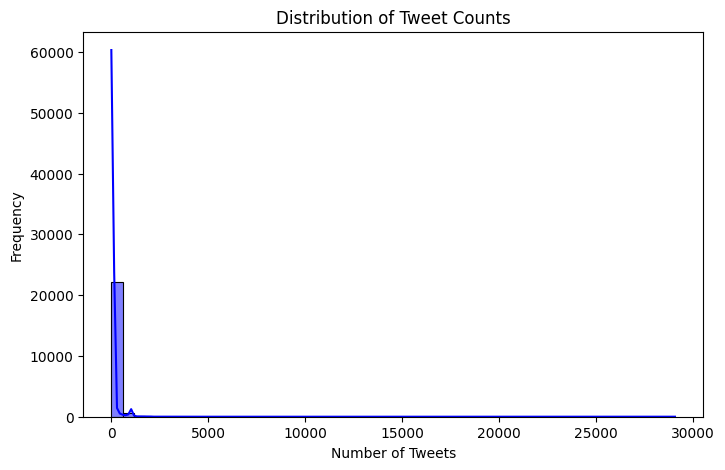

/tmp/ipykernel_9122/2012986401.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='real', data=df, palette='viridis')


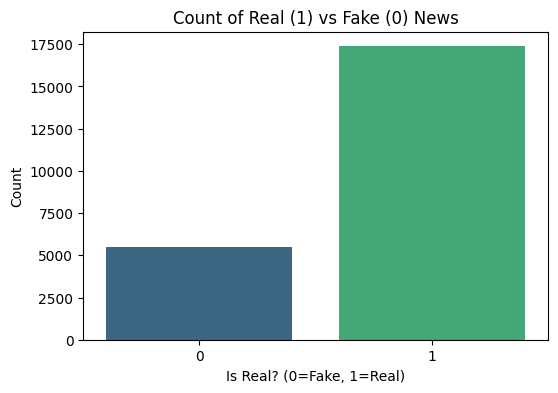

/tmp/ipykernel_9122/2012986401.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='real', y='tweet_num', data=df, palette='pastel')


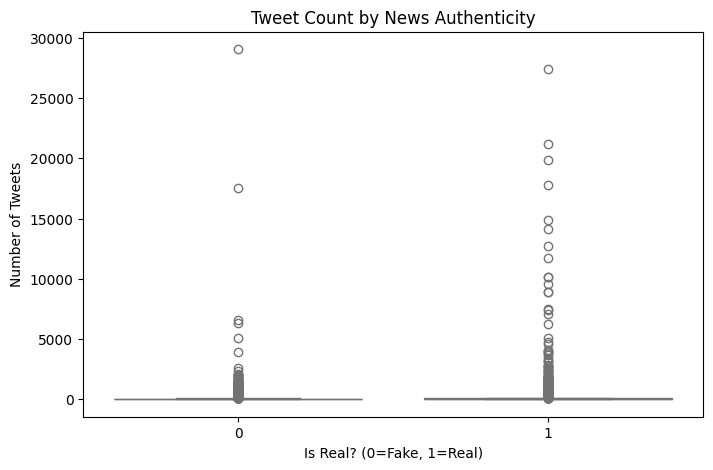

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.histplot(df['tweet_num'], bins=50, kde=True, color='blue')
plt.title('Distribution of Tweet Counts')
plt.xlabel('Number of Tweets')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='real', data=df, palette='viridis')
plt.title('Count of Real (1) vs Fake (0) News')
plt.xlabel('Is Real? (0=Fake, 1=Real)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='real', y='tweet_num', data=df, palette='pastel')
plt.title('Tweet Count by News Authenticity')
plt.xlabel('Is Real? (0=Fake, 1=Real)')
plt.ylabel('Number of Tweets')
plt.show()

Preliminary EDA Findings:
1. tweet_num is concentrating on the lower values, this shows that the data set has outliers
2. The tweet_num of the fake news and real news have significant differences
3. There may be a corelation of tweet interaction and its truth state

Focused Statistical Question: Is there a statistically difference in the tweet number between the fake and real news?

In [8]:
from scipy import stats

real_news = df[df['real'] == 1]['tweet_num']
fake_news = df[df['real'] == 0]['tweet_num']


t_stat, p_value = stats.ttest_ind(real_news, fake_news, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")


T-statistic: -7.469250952430971
P-value: 8.912639483986056e-14


Interpretation of the Statistical Test: Since the p_value is really low this means that our assumption was right which proves that there is a relation between the number of interactions and the truth state of the news article. However it does not mean that there is a reasoning directly but only a relation.

Dataset Evaluation: This dataset is applicable form my project however it is not directly about finance so I may need to find a dataset that is more biased on finance or may be delete some others from this one to test the bot at the end

AI Use Reference: I used AI to remember the syntax of dataframes again. (for some specific commands)